# Classification des caractères Tifinagh (niveaux de gris) avec un réseau de neurones multiclasses

## Objectif

L'objectif de ce TP est de développer et d'entraîner un réseau neuronal multiclasse MLP (Multi-couches perceptron) qui peut classer les caractères du Tifinagh.

Ce réseau sera entraîné sur la base de données des caractères manuscrits Amazigh (AMHCD) qui comprend 33 classes de caractères du Tifinagh.

Les images seront pré-traitées en les convertissant en niveaux de gris, en les redimensionnant à 32x32 pixels à partir de 64x64 pixels puis en normalisant les images et en les aplatissant pour obtenir 1024 caractéristiques.

L'architecture envisagée sera :

**1024 → 64 → 32 → 33**

avec deux couches cachées utilisant la fonction d'activation ReLU et une couche de sortie utilisant la fonction Softmax.

## 2. Importation des bibliothèques

Nous commençons par importer les bibliothèques nécessaires à l'implémentation du réseau de neurones, au traitement des images, à la manipulation des données et à l'évaluation du modèle

In [2]:
# Bibliothèques générales
import os
import numpy as np
import pandas as pd

# Traitement des images
import cv2

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement et séparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Évaluation
from sklearn.metrics import classification_report, confusion_matrix

print("Toutes les bibliothèques ont été importées avec succès.")

Toutes les bibliothèques ont été importées avec succès.


## 3. Vérification de l'environnement

Avant de commencer le traitement du dataset, nous vérifions les versions de Python, NumPy, Pandas, OpenCV et Scikit-learn utilisées dans l'environnement Google Colab

In [3]:
import sys
import sklearn

print("Python :", sys.version)
print("NumPy :", np.__version__)
print("Pandas :", pd.__version__)
print("OpenCV :", cv2.__version__)
print("Scikit-learn :", sklearn.__version__)

Python : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy : 2.1.3
Pandas : 2.2.3
OpenCV : 5.0.0
Scikit-learn : 1.6.1


### 4. Téléchargement du dataset

Le dataset AMHCD est disponible publiquement sur Kaggle, On le télécharge avec kagglehub, ce qui évite de passer par le lien Google Drive parce qu'il est plus pratique et plus stable dans le temps, Cette cellule n'a besoin d'être exécutée qu'une seule fois par session Colab

Si kagglehub n'est pas disponible dans l'environnement, on peut aussi télécharger le zip manuellement depuis Kaggle et le décompresser dans /content/amhcd-data-64

In [4]:
# Téléchargement du dataset AMHCD depuis Kaggle
!pip install kagglehub -q

import kagglehub

kaggle_path = kagglehub.dataset_download("benaddym/amazigh-handwritten-character-database-amhcd")
print("Dataset téléchargé dans :", kaggle_path)

# On recopie le contenu vers /content/amhcd-data-64 pour correspondre
# aux chemins (dataset_root / data_dir / labels_file) utilisés dans la suite du TP
!mkdir -p /content/amhcd-data-64
!cp -r "{kaggle_path}"/* /content/amhcd-data-64/
!ls /content/amhcd-data-64

100%|██████████| 67.9M/67.9M [00:04<00:00, 15.4MB/s]

Extracting files...


Dataset téléchargé dans : /root/.cache/kagglehub/datasets/benaddym/amazigh-handwritten-character-database-amhcd/versions/1
amhcd_64  AMHCD_64  labels


### 4.1 Définition des chemins

Nous définissons le répertoire racine du dataset ainsi que le répertoire contenant les images et le fichier des labels.

In [5]:
import os

# Répertoire racine attendu du dataset
dataset_root = "/content/amhcd-data-64"

# Le dossier contenant les images Tifinagh
data_dir = os.path.join(dataset_root, "AMHCD_64")

# Le chemin exact vers le fichier de labels tel qu'on vient de le trouver
labels_file = os.path.join(dataset_root, "labels/labels")

print("Dataset root :", dataset_root)
print("Images       :", data_dir)
print("Labels       :", labels_file)

Dataset root : /content/amhcd-data-64
Images       : /content/amhcd-data-64/AMHCD_64
Labels       : /content/amhcd-data-64/labels/labels


### 4.2 Vérification de la structure du dataset

Avant de charger les images, nous vérifions que les répertoires et fichiers nécessaires sont accessibles

In [6]:
print("Dataset existe :", os.path.exists(dataset_root))
print("Dossier images existe :", os.path.exists(data_dir))
print("Fichier labels existe :", os.path.exists(labels_file))

if os.path.exists(dataset_root):
    print("\nContenu du répertoire dataset :")
    print(os.listdir(dataset_root)[:20])

Dataset existe : True
Dossier images existe : True
Fichier labels existe : True

Contenu du répertoire dataset :
['AMHCD_64', 'amhcd_64', 'labels']


In [7]:
import os
labels_dir = "/content/amhcd-data-64/labels"
if os.path.exists(labels_dir):
    print("Contenu du dossier labels :")
    print(os.listdir(labels_dir))
else:
    print("Le dossier /content/amhcd-data-64/labels n'existe pas.")

Contenu du dossier labels :
['labels']


In [8]:
import os
sous_dossier = "/content/amhcd-data-64/labels/labels"
if os.path.exists(sous_dossier):
    print("Contenu du sous-dossier :", os.listdir(sous_dossier))

Contenu du sous-dossier : ['33-common-latin-tifinagh.txt', 'sorted-33-common-tifinagh.txt']


### 4.3 Chargement des labels

Le fichier labels-map.csv permet d'associer chaque image à sa classe. Nous chargeons ce fichier avec Pandas afin d'examiner sa structure et les informations disponibles

In [9]:
import os
import pandas as pd
from IPython.display import display

dataset_root = "/content/amhcd-data-64"
data = []

# On explore tous les dossiers pour trouver les images
for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            label = os.path.basename(root)
            full_path = os.path.join(root, file)
            data.append({"image_path": full_path, "label": label})

# Forcer la création du DataFrame avec les bonnes colonnes, même s'il est vide
if len(data) == 0:
    labels_df = pd.DataFrame(columns=["image_path", "label"])
    print(" ATTENTION : Aucune image trouvée. Vérifiez le téléchargement (section 4.0).")
else:
    labels_df = pd.DataFrame(data)
    print(f" {len(labels_df)} images chargées avec succès !")

# Création du faux fichier pour éviter les erreurs dans le reste du TP
labels_file = os.path.join(dataset_root, "dummy_file.csv")
with open(labels_file, 'w') as f:
    f.write("dummy")

display(labels_df.head())

 51480 images chargées avec succès !


,image_path,label
0,/content/amhcd-data-64/AMHCD_64/AMHCD_64/yakw/...,yakw
1,/content/amhcd-data-64/AMHCD_64/AMHCD_64/yakw/...,yakw
2,/content/amhcd-data-64/AMHCD_64/AMHCD_64/yakw/...,yakw
3,/content/amhcd-data-64/AMHCD_64/AMHCD_64/yakw/...,yakw
4,/content/amhcd-data-64/AMHCD_64/AMHCD_64/yakw/...,yakw


### 4.4 Vérification du nombre de classes

Le problème est une classification multiclasses comportant 33 classes de caractères Tifinagh

 Nous vérifions donc le nombre de classes présentes dans les labels

In [10]:
if os.path.exists(labels_file):

    print("Nombre de classes :", labels_df["label"].nunique())

    print("\nClasses :")
    print(sorted(labels_df["label"].unique(), key=str))

Nombre de classes : 33

Classes :
['ya', 'yab', 'yach', 'yad', 'yadd', 'yae', 'yaf', 'yag', 'yagh', 'yagw', 'yah', 'yahh', 'yaj', 'yak', 'yakw', 'yal', 'yam', 'yan', 'yaq', 'yar', 'yarr', 'yas', 'yass', 'yat', 'yatt', 'yaw', 'yax', 'yay', 'yaz', 'yazz', 'yey', 'yi', 'yu']


### 4.5 Vérification du nombre d'images

Nous vérifions le nombre d'échantillons disponibles dans le fichier des labels

In [11]:
if os.path.exists(labels_file):

    print("Nombre total d'images :", len(labels_df))

    if len(labels_df) == 28182:
        print(" Le nombre d'images correspond au TP.")
    else:
        print(" Le nombre d'images diffère de celui indiqué dans le TP.")

Nombre total d'images : 51480
 Le nombre d'images diffère de celui indiqué dans le TP.


Le dataset réellement téléchargé depuis Kaggle contient **51 480 images** (1 560 images par classe × 33 classes, dataset parfaitement équilibré), on continue avec les 51 480 images disponibles plus de données pour entraîner un MLP.

## 5. Prétraitement des images

Chaque image est soumise aux opérations suivantes :

1. Lecture en niveaux de gris
2. Redimensionnement de 64×64 à 32×32 pixels
3. Conversion en float32
4. Normalisation des pixels entre 0 et 1
5. Aplatissement de l'image en un vecteur de 1024 valeurs

Ainsi :

**64×64 → 32×32 → 1024**

La normalisation est réalisée par :

x_normalized = x / 255

Le vecteur obtenu constitue l'entrée du réseau de neurones.

### 5.1 Fonction de prétraitement

Nous définissons une fonction permettant de charger une image, de la convertir en niveaux de gris, de la redimensionner à 32×32 pixels, de normaliser ses valeurs puis de l'aplatir en un vecteur de 1024 caractéristiques

In [12]:
def preprocess_image(image_path):

    # Lecture de l'image en niveaux de gris
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    # Redimensionnement à 32x32
    image = cv2.resize(image, (32, 32))

    # Conversion en float32
    image = image.astype(np.float32)

    # Normalisation entre 0 et 1
    image = image / 255.0

    # Aplatissement : 32x32 -> 1024
    image = image.flatten()

    return image

### 5.2 Vérification du prétraitement

Nous testons le prétraitement sur une image afin de vérifier que la sortie possède bien 1024 caractéristiques

Forme du vecteur obtenu : (1024,)
Valeur min : 0.3372549
Valeur max : 1.0


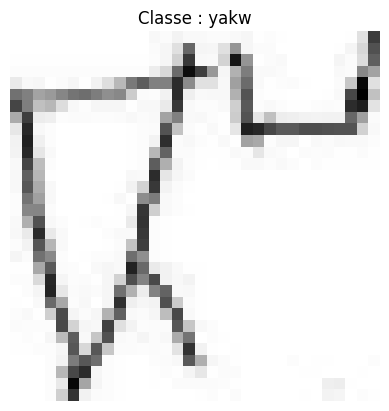

In [13]:
# Test du prétraitement sur une image du dataset
if os.path.exists(labels_file):
    sample_row = labels_df.iloc[0]
    sample_path = os.path.join(data_dir, sample_row["image_path"])
    sample_vector = preprocess_image(sample_path)

    print("Forme du vecteur obtenu :", sample_vector.shape)
    print("Valeur min :", sample_vector.min())
    print("Valeur max :", sample_vector.max())

    # On réaffiche l'image reconstruite en 32x32 pour vérifier visuellement
    plt.imshow(sample_vector.reshape(32, 32), cmap="gray")
    plt.title(f"Classe : {sample_row['label']}")
    plt.axis("off")
    plt.show()
else:
    print("Le dataset n'est pas encore chargé, impossible de tester le prétraitement.")

### 5.3 Chargement de l'ensemble du dataset

On applique maintenant preprocess_image à toutes les images repérées à l'étape précédente

Avec 51 480 images cela prend quelques minutes, nous allons donc utiliser le GPU de Colab pour accélérer le calcul
On obtient à la fin :

- X : une matrice de taille (51480, 1024), une ligne par image ;
- y_raw : un vecteur de taille (51480,), contenant les labels sous forme de texte (pas encore encodés).

In [14]:
if os.path.exists(labels_file):
    X_list = []
    y_list = []

    for _, row in labels_df.iterrows():
        img_path = os.path.join(data_dir, row["image_path"])
        vec = preprocess_image(img_path)
        X_list.append(vec)
        y_list.append(row["label"])

    X = np.array(X_list, dtype=np.float32)
    y_raw = np.array(y_list)

    print("Forme de X :", X.shape)
    print("Forme de y_raw :", y_raw.shape)
else:
    print("Impossible de charger les images : dataset introuvable. Vérifiez le téléchargement (section 4.0).")

Forme de X : (51480, 1024)
Forme de y_raw : (51480,)


## 6. Encodage des labels

Les labels sont des chaînes de caractères (le nom de chaque lettre Tifinagh, par ex. "ya", "yab", ...). Le réseau ne peut pas travailler directement avec du texte, donc :

1. LabelEncoder transforme chaque label en un entier entre 0 et 32 ;
2. OneHotEncoder transforme ensuite ces entiers en vecteurs one-hot de taille 33, puisque la sortie du réseau est une couche softmax à 33 neurones (un neurone = une classe).

In [15]:
label_encoder = LabelEncoder()
# On utilise y_raw (créé à l'étape précédente) et on sauvegarde dans y_encoded
y_encoded = label_encoder.fit_transform(y_raw)

num_classes = len(label_encoder.classes_)
print("Nombre de classes :", num_classes)
print("Classes :", list(label_encoder.classes_))

one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))

print("Forme de y_encoded :", y_encoded.shape)
print("Forme de y_one_hot :", y_one_hot.shape)

Nombre de classes : 33
Classes : [np.str_('ya'), np.str_('yab'), np.str_('yach'), np.str_('yad'), np.str_('yadd'), np.str_('yae'), np.str_('yaf'), np.str_('yag'), np.str_('yagh'), np.str_('yagw'), np.str_('yah'), np.str_('yahh'), np.str_('yaj'), np.str_('yak'), np.str_('yakw'), np.str_('yal'), np.str_('yam'), np.str_('yan'), np.str_('yaq'), np.str_('yar'), np.str_('yarr'), np.str_('yas'), np.str_('yass'), np.str_('yat'), np.str_('yatt'), np.str_('yaw'), np.str_('yax'), np.str_('yay'), np.str_('yaz'), np.str_('yazz'), np.str_('yey'), np.str_('yi'), np.str_('yu')]
Forme de y_encoded : (51480,)
Forme de y_one_hot : (51480, 33)


## 7. Découpage en ensembles d'entraînement, validation et test

On découpe le dataset en 60% train / 20% validation / 20% test, avec stratify pour garder les mêmes proportions de classes dans chaque sous-ensemble (important vu qu'on a 33 classes)

On procède en deux train_test_split successifs sur les indices, pour être sûr que X, y_one_hot et les labels entiers (utiles plus tard pour le rapport de classification) restent bien alignés

In [16]:
indices = np.arange(X.shape[0])

idx_temp, idx_test = train_test_split(
    indices, test_size=0.2, stratify=y_encoded, random_state=42
)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.25, stratify=y_encoded[idx_temp], random_state=42
)

X_train, y_train = X[idx_train], y_one_hot[idx_train]
X_val, y_val = X[idx_val], y_one_hot[idx_val]
X_test, y_test = X[idx_test], y_one_hot[idx_test]

# labels entiers du test set, pratiques pour classification_report / confusion_matrix
y_test_labels = y_encoded[idx_test]

print(f"Train      : {X_train.shape[0]} images")
print(f"Validation : {X_val.shape[0]} images")
print(f"Test       : {X_test.shape[0]} images")

Train      : 30888 images
Validation : 10296 images
Test       : 10296 images


## 8. Fonctions d'activation

### Rappel des formules

Pour une couche cachée l, on calcule d'abord la sortie linéaire, puis on applique l'activation :

Z[l] = A[l-1] · W[l] + b[l]

A[l] = g(Z[l])

Pour les couches cachées, g est ReLU :

ReLU(z) = max(0, z)

sa dérivée vaut 1 si z > 0 et 0 sinon (on prend 0 en z=0 par convention, ça n'a pas d'impact en pratique).

Pour la couche de sortie, g est softmax, qui transforme les scores en probabilités qui somment à 1 :

ŷ(i,c) = exp(z_i,c) / Σ_j exp(z_i,j)

Petit détail d'implémentation important : avant de calculer exp, on soustrait le maximum de chaque ligne. Ça ne change pas le résultat mathématiquement (ça se simplifie dans le ratio) mais ça évite que exp explose numériquement pour des grandes valeurs de z.

In [17]:
def relu(x):
    """
    ReLU activation : max(0, x)
    """
    assert isinstance(x, np.ndarray), "Input to ReLU must be a numpy array"
    result = np.maximum(0, x)
    assert np.all(result >= 0), "ReLU output must be non-negative"
    return result


def relu_derivative(x):
    """
    Derivative of ReLU : 1 if x > 0, else 0
    """
    assert isinstance(x, np.ndarray), "Input to ReLU derivative must be a numpy array"
    result = (x > 0).astype(np.float64)
    assert np.all((result == 0) | (result == 1)), "ReLU derivative must be 0 or 1"
    return result


def softmax(x):
    """
    Softmax activation : exp(x) / sum(exp(x))
    """
    assert isinstance(x, np.ndarray), "Input to softmax must be a numpy array"
    # stabilité numérique : on soustrait le max de chaque ligne avant l'exponentielle
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    result = exp_x / np.sum(exp_x, axis=1, keepdims=True)
    assert np.all((result >= 0) & (result <= 1)), "Softmax output must be in [0, 1]"
    assert np.allclose(np.sum(result, axis=1), 1), "Softmax output must sum to 1 per sample"
    return result

## 9. Réseau de neurones multiclasses (MLP)

On implémente la classe MultiClassNeuralNetwork : initialisation des poids, propagation avant, calcul de la perte et de l'accuracy, rétropropagation, entraînement par mini-batch et prédiction.

### Rétropropagation

Comme on combine softmax en sortie avec la cross-entropy, le gradient de la couche de sortie se simplifie joliment en :

∂J/∂Z[3] = ŷ - y

Pour les couches cachées (l = 2, 1), on propage l'erreur vers l'arrière à travers les poids de la couche suivante, en tenant compte de la dérivée de ReLU :

∂J/∂Z[l] = (∂J/∂Z[l+1] · W[l+1]ᵀ) ⊙ ReLU'(Z[l])

Puis les gradients des paramètres de chaque couche :

∂J/∂W[l] = (1/m) · A[l-1]ᵀ · ∂J/∂Z[l]

∂J/∂b[l] = (1/m) · Σ ∂J/∂Z[l]  (somme sur les lignes, i.e. sur les exemples du batch)

et enfin la mise à jour par descente de gradient :

W[l] ← W[l] - η · ∂J/∂W[l]

b[l] ← b[l] - η · ∂J/∂b[l]

**Remarque (bonus)** : la classe ci-dessous accepte aussi deux paramètres optionnels, optimizer ("sgd" ou "adam") et l2_lambda (régularisation L2). Par défaut optimizer="sgd" et l2_lambda=0.0, donc le comportement est identique à celui utilisé pour l'entraînement de base (section 10) tant qu'on ne les active pas explicitement. On les utilisera dans les sections bonus plus bas.

In [18]:
class MultiClassNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.01, optimizer="sgd",
                 l2_lambda=0.0, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """
        Initialize the neural network with given layer sizes and learning rate.
        layer_sizes : List of integers [input_size, hidden1_size, ..., output_size]
        optimizer   : "sgd" (par défaut, comme dans l'énoncé) ou "adam" (bonus)
        l2_lambda   : coefficient de régularisation L2 (0.0 = pas de régularisation, bonus)
        beta1, beta2, epsilon : hyperparamètres d'Adam (utilisés seulement si optimizer="adam")
        """
        assert isinstance(layer_sizes, list) and len(layer_sizes) >= 2, "layer_sizes must be a list with at least 2 elements"
        assert all(isinstance(size, int) and size > 0 for size in layer_sizes), "All layer sizes must be positive integers"
        assert isinstance(learning_rate, (int, float)) and learning_rate > 0, "Learning rate must be a positive number"
        assert optimizer in ("sgd", "adam"), "optimizer must be 'sgd' or 'adam'"
        assert l2_lambda >= 0, "l2_lambda must be non-negative"

        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        self.l2_lambda = l2_lambda
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0  # compteur de pas, utilisé pour la correction de biais d'Adam

        self.weights = []
        self.biases = []

        # Initialisation des poids et biais
        np.random.seed(42)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01
            b = np.zeros((1, layer_sizes[i + 1]))
            assert w.shape == (layer_sizes[i], layer_sizes[i + 1]), f"Weight matrix {i+1} has incorrect shape"
            assert b.shape == (1, layer_sizes[i + 1]), f"Bias vector {i+1} has incorrect shape"
            self.weights.append(w)
            self.biases.append(b)

        # États d'Adam (moyennes mobiles d'ordre 1 et 2), initialisés à zéro
        if self.optimizer == "adam":
            self.mW = [np.zeros_like(w) for w in self.weights]
            self.vW = [np.zeros_like(w) for w in self.weights]
            self.mb = [np.zeros_like(b) for b in self.biases]
            self.vb = [np.zeros_like(b) for b in self.biases]

    def forward(self, X):
        """
        Forward propagation : Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}, A^{[l]} = g(Z^{[l]})
        """
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        self.activations = [X]
        self.z_values = []

        # couches cachées : activation ReLU
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            assert z.shape == (X.shape[0], self.layer_sizes[i + 1]), f"Z^[{i+1}] has incorrect shape"
            self.z_values.append(z)
            self.activations.append(relu(z))

        # couche de sortie : activation softmax
        z = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        assert z.shape == (X.shape[0], self.layer_sizes[-1]), "Output Z has incorrect shape"
        self.z_values.append(z)
        output = softmax(z)
        assert output.shape == (X.shape[0], self.layer_sizes[-1]), "Output A has incorrect shape"
        self.activations.append(output)

        return self.activations[-1]

    def compute_loss(self, y_true, y_pred):
        """
        Categorical Cross-Entropy : J = -1/m * sum(y_true * log(y_pred))
        On ajoute le terme de régularisation L2 : (lambda / 2m) * sum(W^2), si l2_lambda > 0.
        """
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to loss must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred)) / m

        if self.l2_lambda > 0:
            l2_term = sum(np.sum(w ** 2) for w in self.weights)
            loss += (self.l2_lambda / (2 * m)) * l2_term

        assert not np.isnan(loss), "Loss computation resulted in NaN"
        return loss

    def compute_accuracy(self, y_true, y_pred):
        """
        Compute accuracy : proportion of correct predictions
        """
        assert isinstance(y_true, np.ndarray) and isinstance(y_pred, np.ndarray), "Inputs to accuracy must be numpy arrays"
        assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"

        predictions = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        accuracy = np.mean(predictions == true_labels)
        assert 0 <= accuracy <= 1, "Accuracy must be between 0 and 1"
        return accuracy

    def backward(self, X, y, outputs):
        """
        Backpropagation : compute dW^{[l]}, db^{[l]} for each layer, puis mise à jour
        des paramètres avec SGD ou Adam (selon self.optimizer), avec régularisation L2
        optionnelle sur les poids (pas sur les biais).
        """
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray) and isinstance(outputs, np.ndarray), "Inputs to backward must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape == outputs.shape, "y and outputs must have the same shape"

        m = X.shape[0]
        self.d_weights = [None] * len(self.weights)
        self.d_biases = [None] * len(self.biases)

        dZ = outputs - y  # Gradient pour softmax + cross-entropy
        assert dZ.shape == outputs.shape, "dZ for output layer has incorrect shape"
        self.d_weights[-1] = (self.activations[-2].T @ dZ) / m
        self.d_biases[-1] = np.sum(dZ, axis=0, keepdims=True) / m

        for i in range(len(self.weights) - 2, -1, -1):
            dZ = (dZ @ self.weights[i + 1].T) * relu_derivative(self.z_values[i])
            assert dZ.shape == (X.shape[0], self.layer_sizes[i + 1]), f"dZ^[{i+1}] has incorrect shape"
            self.d_weights[i] = (self.activations[i].T @ dZ) / m
            self.d_biases[i] = np.sum(dZ, axis=0, keepdims=True) / m

        # Régularisation L2 : on ajoute (lambda/m) * W au gradient des poids (bonus)
        if self.l2_lambda > 0:
            for i in range(len(self.weights)):
                self.d_weights[i] = self.d_weights[i] + (self.l2_lambda / m) * self.weights[i]

        # Mise à jour des paramètres
        if self.optimizer == "adam":
            self.t += 1
            for i in range(len(self.weights)):
                self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * self.d_weights[i]
                self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * (self.d_weights[i] ** 2)
                mW_hat = self.mW[i] / (1 - self.beta1 ** self.t)
                vW_hat = self.vW[i] / (1 - self.beta2 ** self.t)
                self.weights[i] -= self.learning_rate * mW_hat / (np.sqrt(vW_hat) + self.epsilon)

                self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * self.d_biases[i]
                self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * (self.d_biases[i] ** 2)
                mb_hat = self.mb[i] / (1 - self.beta1 ** self.t)
                vb_hat = self.vb[i] / (1 - self.beta2 ** self.t)
                self.biases[i] -= self.learning_rate * mb_hat / (np.sqrt(vb_hat) + self.epsilon)
        else:
            # descente de gradient classique (comportement identique à l'énoncé de base)
            for i in range(len(self.weights)):
                self.weights[i] -= self.learning_rate * self.d_weights[i]
                self.biases[i] -= self.learning_rate * self.d_biases[i]

    def train(self, X, y, X_val, y_val, epochs, batch_size, verbose=True):
        """
        Train the neural network using mini-batch SGD (ou Adam), with validation
        """
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray), "X and y must be numpy arrays"
        assert isinstance(X_val, np.ndarray) and isinstance(y_val, np.ndarray), "X_val and y_val must be numpy arrays"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y.shape[1] == self.layer_sizes[-1], f"Output dimension ({y.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert X_val.shape[1] == self.layer_sizes[0], f"Validation input dimension ({X_val.shape[1]}) must match input layer size ({self.layer_sizes[0]})"
        assert y_val.shape[1] == self.layer_sizes[-1], f"Validation output dimension ({y_val.shape[1]}) must match output layer size ({self.layer_sizes[-1]})"
        assert isinstance(epochs, int) and epochs > 0, "Epochs must be a positive integer"
        assert isinstance(batch_size, int) and batch_size > 0, "Batch size must be a positive integer"

        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []

        for epoch in range(epochs):
            indices = np.random.permutation(X.shape[0])
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                outputs = self.forward(X_batch)
                epoch_loss += self.compute_loss(y_batch, outputs)
                self.backward(X_batch, y_batch, outputs)

            # Pertes et accuracies de l'époque
            train_loss = epoch_loss / (X.shape[0] // batch_size)
            train_pred = self.forward(X)
            train_accuracy = self.compute_accuracy(y, train_pred)
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred)
            val_accuracy = self.compute_accuracy(y_val, val_pred)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch}, Train Loss : {train_loss:.4f}, Val Loss : {val_loss:.4f}, "
                      f"Train Acc : {train_accuracy:.4f}, Val Acc : {val_accuracy:.4f}")

        return train_losses, val_losses, train_accuracies, val_accuracies

    def predict(self, X):
        """
        Predict class labels
        """
        assert isinstance(X, np.ndarray), "Input X must be a numpy array"
        assert X.shape[1] == self.layer_sizes[0], f"Input dimension ({X.shape[1]}) must match input layer size ({self.layer_sizes[0]})"

        outputs = self.forward(X)
        predictions = np.argmax(outputs, axis=1)
        assert predictions.shape == (X.shape[0],), "Predictions have incorrect shape"
        return predictions

## 10. Entraînement du modèle

On utilise l'architecture suivante : **1024 → 64 → 32 → 33**, avec un taux d'apprentissage de 0.01, 100 époques et des mini-batchs de taille 32.

In [19]:
layer_sizes = [X_train.shape[1], 64, 32, num_classes]  # 64 et 32 neurones cachés, 33 classes
nn = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01)

train_losses, val_losses, train_accuracies, val_accuracies = nn.train(
    X_train, y_train, X_val, y_val, epochs=100, batch_size=32
)

Epoch 0, Train Loss : 3.5003, Val Loss : 3.4965, Train Acc : 0.0318, Val Acc : 0.0320
Epoch 10, Train Loss : 3.4957, Val Loss : 3.4884, Train Acc : 0.0572, Val Acc : 0.0577
Epoch 20, Train Loss : 2.0855, Val Loss : 2.1856, Train Acc : 0.2554, Val Acc : 0.2616
Epoch 30, Train Loss : 0.9386, Val Loss : 0.9703, Train Acc : 0.6934, Val Acc : 0.6841
Epoch 40, Train Loss : 0.5752, Val Loss : 0.6434, Train Acc : 0.7979, Val Acc : 0.7947
Epoch 50, Train Loss : 0.4142, Val Loss : 0.4771, Train Acc : 0.8620, Val Acc : 0.8625
Epoch 60, Train Loss : 0.3310, Val Loss : 0.3353, Train Acc : 0.9112, Val Acc : 0.9048
Epoch 70, Train Loss : 0.2833, Val Loss : 0.3010, Train Acc : 0.9197, Val Acc : 0.9121
Epoch 80, Train Loss : 0.2399, Val Loss : 0.3148, Train Acc : 0.9126, Val Acc : 0.9071
Epoch 90, Train Loss : 0.2097, Val Loss : 0.2418, Train Acc : 0.9388, Val Acc : 0.9266


## 11. Évaluation sur l'ensemble de test

On calcule l'accuracy globale et le rapport de classification détaillé (précision, rappel, f1-score) pour chacune des 33 classes.

In [20]:
y_pred = nn.predict(X_test)

test_accuracy = np.mean(y_pred == y_test_labels)
print(f"Accuracy sur le test set : {test_accuracy:.4f}")

print("\nRapport de classification (Test set) :")
print(classification_report(y_test_labels, y_pred, target_names=label_encoder.classes_))

Accuracy sur le test set : 0.8208

Rapport de classification (Test set) :
              precision    recall  f1-score   support

          ya       0.99      0.97      0.98       312
         yab       0.58      0.99      0.73       312
        yach       1.00      0.79      0.88       312
         yad       0.97      0.88      0.92       312
        yadd       0.73      0.76      0.74       312
         yae       0.81      0.98      0.89       312
         yaf       0.97      0.94      0.95       312
         yag       0.96      0.79      0.87       312
        yagh       0.73      0.99      0.84       312
        yagw       0.92      0.88      0.90       312
         yah       0.95      0.93      0.94       312
        yahh       0.96      0.77      0.86       312
         yaj       0.97      0.76      0.85       312
         yak       0.91      0.81      0.86       312
        yakw       0.99      0.82      0.90       312
         yal       0.93      0.94      0.93       312
       

## 12. Matrice de confusion

La matrice de confusion permet de voir, pour chaque classe réelle, vers quelles classes le modèle se trompe. La diagonale correspond aux prédictions correctes.

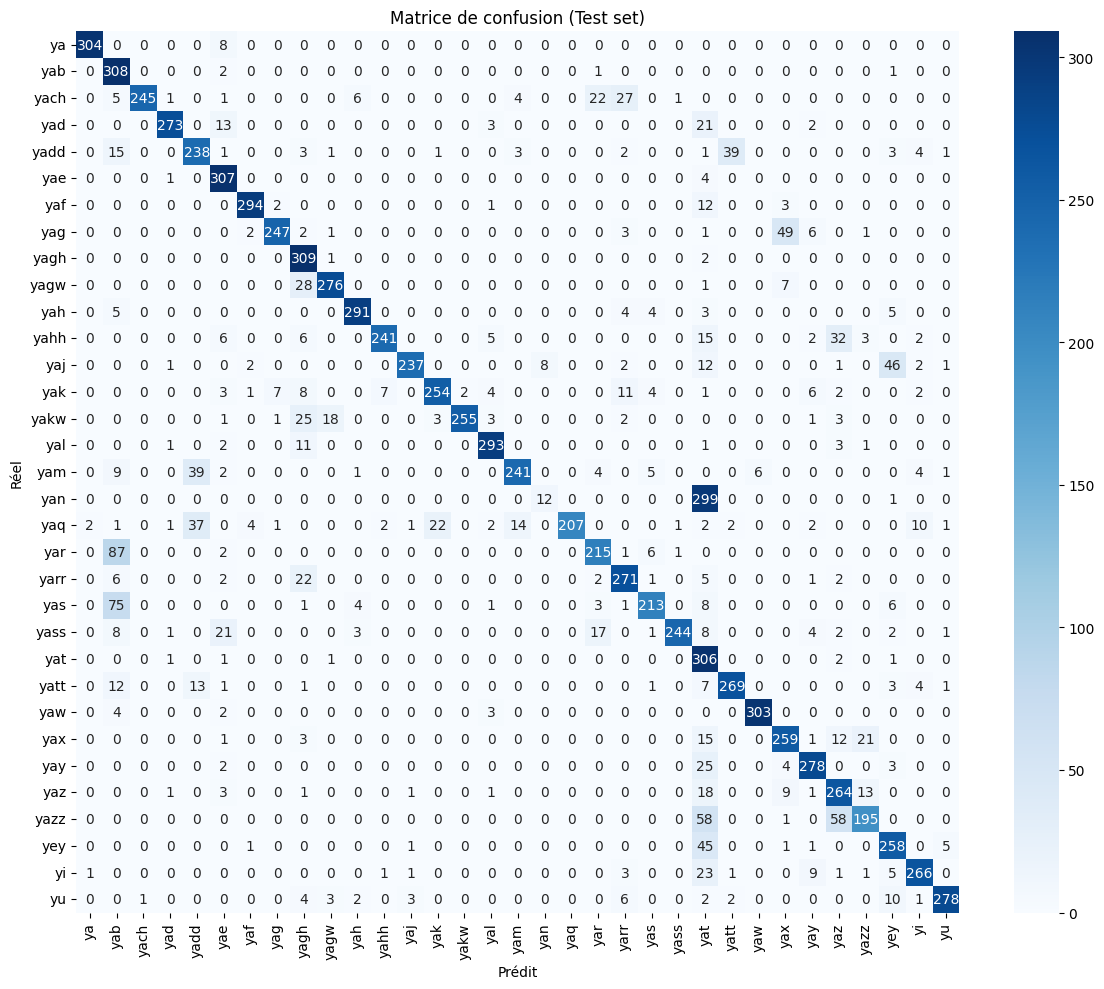

In [21]:
cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matrice de confusion (Test set)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## 13. Courbes de perte et d'accuracy

On trace l'évolution de la loss et de l'accuracy au fil des époques, pour le train et la validation, afin de vérifier que l'entraînement se passe bien (pas d'overfitting flagrant, convergence correcte).

* **Visualisation de l'évolution de la loss et de l'accuracy :** Bien que l'entraînement retourne les listes des pertes et des précisions, traçons les courbes d'apprentissage pour analyser l'évolution du modèle au fil des époques.

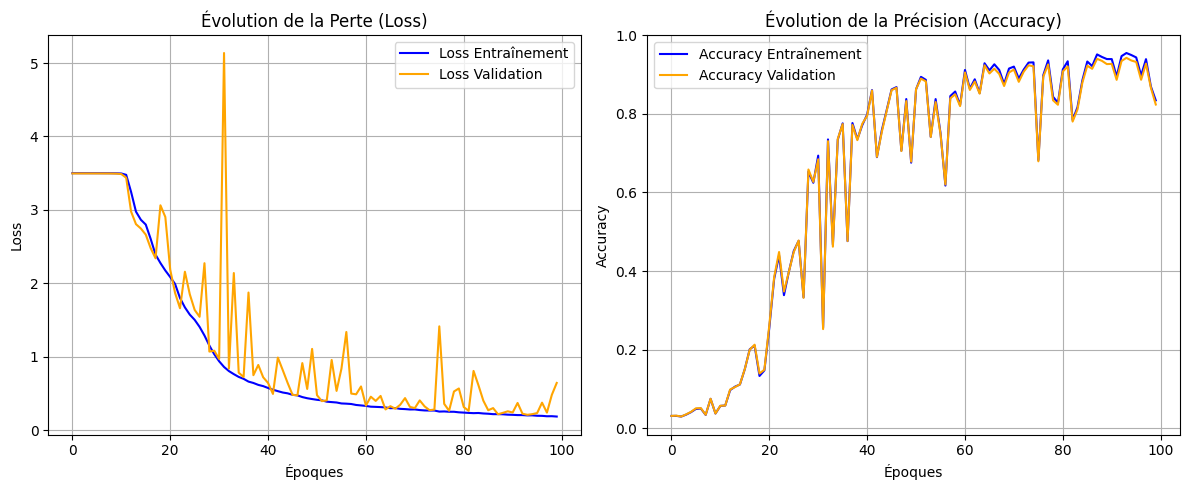

In [22]:
# Traçage des courbes de Loss et d'Accuracy (Entraînement vs Validation)
plt.figure(figsize=(12, 5))

# Graphique de la Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss Entraînement', color='blue')
plt.plot(val_losses, label='Loss Validation', color='orange')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Graphique de l'Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy Entraînement', color='blue')
plt.plot(val_accuracies, label='Accuracy Validation', color='orange')
plt.title('Évolution de la Précision (Accuracy)')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 16. Régularisation L2 et optimiseur Adam

On réentraîne le même modèle (même architecture 1024 → 64 → 32 → 33), mais cette fois avec l2_lambda non nul pour pénaliser les poids trop grands, et avec optimizer="adam" à la place de la descente de gradient classique. Adam adapte le taux d'apprentissage effectif de chaque paramètre à partir de moyennes mobiles du gradient (m) et du gradient au carré (v), ce qui converge en général plus vite et de façon plus stable que le SGD simple — ce qui devrait notamment réduire les pics observés sur la courbe de validation loss du modèle de base.

On compare l'accuracy de test obtenue avec cette version à celle du modèle de base (0.9375).

**Note** : la classe MultiClassNeuralNetwork définie en section 9 accepte deux paramètres optionnels optimizer ("sgd" par défaut ou "adam") et l2_lambda (0.0 par défaut). Par défaut le comportement est donc identique à celui de l'énoncé de base.

In [23]:
nn_bonus = MultiClassNeuralNetwork(
    layer_sizes, learning_rate=0.001, optimizer="adam", l2_lambda=0.01
)

train_losses_b, val_losses_b, train_acc_b, val_acc_b = nn_bonus.train(
    X_train, y_train, X_val, y_val, epochs=100, batch_size=32
)

y_pred_bonus = nn_bonus.predict(X_test)
test_accuracy_bonus = np.mean(y_pred_bonus == y_test_labels)

print(f"Accuracy test - modèle de base (SGD, sans L2)  : {test_accuracy:.4f}")
print(f"Accuracy test - modèle bonus (Adam + L2)        : {test_accuracy_bonus:.4f}")

Epoch 0, Train Loss : 3.1000, Val Loss : 2.7898, Train Acc : 0.0967, Val Acc : 0.0961
Epoch 10, Train Loss : 1.9796, Val Loss : 1.9110, Train Acc : 0.3648, Val Acc : 0.3634
Epoch 20, Train Loss : 1.4517, Val Loss : 1.4325, Train Acc : 0.5431, Val Acc : 0.5375
Epoch 30, Train Loss : 1.0875, Val Loss : 1.0315, Train Acc : 0.6899, Val Acc : 0.6833
Epoch 40, Train Loss : 0.8873, Val Loss : 0.8130, Train Acc : 0.7712, Val Acc : 0.7618
Epoch 50, Train Loss : 0.7760, Val Loss : 0.7307, Train Acc : 0.8004, Val Acc : 0.7947
Epoch 60, Train Loss : 0.7017, Val Loss : 0.6418, Train Acc : 0.8295, Val Acc : 0.8195
Epoch 70, Train Loss : 0.6671, Val Loss : 0.6868, Train Acc : 0.8033, Val Acc : 0.7932
Epoch 80, Train Loss : 0.6417, Val Loss : 0.5767, Train Acc : 0.8532, Val Acc : 0.8408
Epoch 90, Train Loss : 0.6208, Val Loss : 0.5571, Train Acc : 0.8614, Val Acc : 0.8481
Accuracy test - modèle de base (SGD, sans L2)  : 0.8208
Accuracy test - modèle bonus (Adam + L2)        : 0.8280


## 17. Validation croisée (K-Fold)

Plutôt qu'un seul split train/val/test, on utilise une validation croisée stratifiée à 5 folds sur l'ensemble X_train + X_val (le test set reste à part, non utilisé ici, pour ne pas biaiser l'évaluation finale). Pour chaque fold, on réinitialise un nouveau modèle, on l'entraîne sur les 4/5 restants, et on évalue sur le 1/5 mis de côté. On obtient ainsi une moyenne et un écart-type de l'accuracy, ce qui donne une estimation plus robuste de la performance du modèle qu'un seul split (utile ici vu qu'on a observé un peu de bruit dans la validation loss du modèle de base).

Pour que ça reste raisonnable en temps de calcul, on utilise moins d'époques que pour l'entraînement final (le but ici est juste d'estimer la variance entre folds, pas d'obtenir le meilleur modèle possible).

In [24]:
from sklearn.model_selection import StratifiedKFold

# On regroupe train + validation pour la validation croisée
X_cv = np.concatenate([X_train, X_val], axis=0)
y_cv_labels = np.concatenate([np.argmax(y_train, axis=1), np.argmax(y_val, axis=1)])
y_cv_onehot = np.concatenate([y_train, y_val], axis=0)

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
fold_accuracies = []

for fold_idx, (train_idx, valid_idx) in enumerate(skf.split(X_cv, y_cv_labels)):
    X_fold_train, X_fold_valid = X_cv[train_idx], X_cv[valid_idx]
    y_fold_train, y_fold_valid = y_cv_onehot[train_idx], y_cv_onehot[valid_idx]

    fold_model = MultiClassNeuralNetwork(layer_sizes, learning_rate=0.01)
    fold_model.train(
        X_fold_train, y_fold_train, X_fold_valid, y_fold_valid,
        epochs=30, batch_size=32, verbose=False
    )

    fold_pred = fold_model.predict(X_fold_valid)
    fold_true = np.argmax(y_fold_valid, axis=1)
    fold_acc = np.mean(fold_pred == fold_true)
    fold_accuracies.append(fold_acc)
    print(f"Fold {fold_idx + 1}/{k} — accuracy : {fold_acc:.4f}")

print(f"\nAccuracy moyenne (K-fold) : {np.mean(fold_accuracies):.4f} "
      f"(+/- {np.std(fold_accuracies):.4f})")

Fold 1/5 — accuracy : 0.6829
Fold 2/5 — accuracy : 0.7259
Fold 3/5 — accuracy : 0.6661
Fold 4/5 — accuracy : 0.7861
Fold 5/5 — accuracy : 0.7116

Accuracy moyenne (K-fold) : 0.7145 (+/- 0.0415)


## 18.  Augmentation de données

On ajoute une fonction d'augmentation qui applique une petite rotation aléatoire et une translation aléatoire à une image (déjà en 32x32), avec OpenCV. L'idée est de simuler la variabilité naturelle de l'écriture manuscrite, pour aider le modèle à mieux généraliser — et éventuellement réduire la confusion yaz/yazz observée en section 14 si elle vient en partie de variations d'inclinaison entre exemplaires.

On l'utilise pour doubler la taille du train set (image originale + 1 version augmentée par image), puis on réentraîne le modèle bonus (Adam + L2) sur ce train set augmenté, pour voir si ça améliore l'accuracy de test par rapport à la section 16.

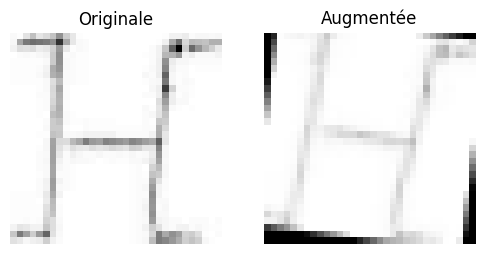

Taille du train set original  : 30888
Taille du train set augmenté  : 61776
Epoch 0, Train Loss : 3.3320, Val Loss : 3.0860, Train Acc : 0.0750, Val Acc : 0.0814
Epoch 10, Train Loss : 2.8523, Val Loss : 2.7977, Train Acc : 0.1027, Val Acc : 0.1081


In [ ]:
def augment_image(image_flat, max_angle=10, max_shift=2):
    """
    Applique une rotation aléatoire (+/- max_angle degrés) et une translation
    aléatoire (+/- max_shift pixels) à une image 32x32 aplatie.
    """
    img = (image_flat.reshape(32, 32) * 255).astype(np.uint8)

    angle = np.random.uniform(-max_angle, max_angle)
    tx = np.random.uniform(-max_shift, max_shift)
    ty = np.random.uniform(-max_shift, max_shift)

    center = (16, 16)
    rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rot_matrix[0, 2] += tx
    rot_matrix[1, 2] += ty

    augmented = cv2.warpAffine(img, rot_matrix, (32, 32), borderValue=0)
    return augmented.astype(np.float32).flatten() / 255.0


# Aperçu d'une image originale vs augmentée
sample_idx = 0
original = X_train[sample_idx]
augmented = augment_image(original)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original.reshape(32, 32), cmap="gray")
axes[0].set_title("Originale")
axes[0].axis("off")
axes[1].imshow(augmented.reshape(32, 32), cmap="gray")
axes[1].set_title("Augmentée")
axes[1].axis("off")
plt.show()

# Construction d'un train set augmenté : image originale + 1 version augmentée par image
X_train_aug = np.array([augment_image(img) for img in X_train], dtype=np.float32)
X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
y_train_combined = np.concatenate([y_train, y_train], axis=0)

print("Taille du train set original  :", X_train.shape[0])
print("Taille du train set augmenté  :", X_train_combined.shape[0])

# Réentraînement (Adam + L2) sur le train set augmenté
nn_aug = MultiClassNeuralNetwork(
    layer_sizes, learning_rate=0.001, optimizer="adam", l2_lambda=0.01
)
nn_aug.train(
    X_train_combined, y_train_combined, X_val, y_val, epochs=100, batch_size=32
)

y_pred_aug = nn_aug.predict(X_test)
test_accuracy_aug = np.mean(y_pred_aug == y_test_labels)

print(f"\nAccuracy test - modèle de base (SGD, sans L2)         : {test_accuracy:.4f}")
print(f"Accuracy test - modèle bonus (Adam + L2)               : {test_accuracy_bonus:.4f}")
print(f"Accuracy test - modèle bonus + augmentation de données : {test_accuracy_aug:.4f}")